### GO-Enriched Hybrid Text + Sequence Clustering (Upgraded Pipeline)

**Cell 1 — Load Data & Existing Embeddings**

In [1]:
import pandas as pd
import numpy as np
import scipy.sparse
import re
import requests
import time
import json
import os

# ── Load data ──────────────────────────────────────────────────────────────
text_df = pd.read_csv('../data/processed/uniprot_all_fields_cache.csv')
text_df = text_df.rename(columns={'Entry': 'ID'})
master_ids = text_df['ID'].tolist()

# ── Load existing embeddings ───────────────────────────────────────────────
sbert_embeddings = np.load('../data/processed/embeddings_sbert.npy')
tfidf_embeddings = scipy.sparse.load_npz('../data/processed/embeddings_tfidf.npz')

print(f'Dataset loaded: {len(master_ids)} proteins')
print(f'TF-IDF shape : {tfidf_embeddings.shape}')
print(f'SBERT shape  : {sbert_embeddings.shape}')

Dataset loaded: 1037 proteins
TF-IDF shape : (1037, 343)
SBERT shape  : (1037, 384)


**Cell 2 — Fetch & Cache GO Definitions from QuickGO API**

In [2]:
GO_CACHE_PATH = '../data/processed/go_definitions_cache.json'

# Load cache if it exists — avoids re-fetching every run
if os.path.exists(GO_CACHE_PATH):
    with open(GO_CACHE_PATH, 'r') as f:
        go_definitions = json.load(f)
    print(f'Loaded {len(go_definitions)} GO definitions from cache.')
else:
    # Extract all unique GO codes from dataset
    go_codes = set()
    for entry in text_df['Gene Ontology (GO)'].dropna():
        codes = re.findall(r'GO:\d+', entry)
        go_codes.update(codes)
    print(f'Total unique GO codes to fetch: {len(go_codes)}')

    go_definitions = {}
    failed = []

    for go_id in go_codes:
        url = f'https://www.ebi.ac.uk/QuickGO/services/ontology/go/terms/{go_id}'
        try:
            r = requests.get(url, headers={'Accept': 'application/json'}, timeout=10)
            if r.status_code == 200:
                result = r.json()['results'][0]
                go_definitions[go_id] = {
                    'name'      : result['name'],
                    'definition': result.get('definition', {}).get('text', ''),
                    # aspect: P=Biological Process, F=Molecular Function, C=Cellular Component
                    'aspect'    : result.get('aspect', '')
                }
        except Exception as e:
            failed.append(go_id)
        time.sleep(0.1)  # polite to the API

    # Persist cache so future runs are instant
    with open(GO_CACHE_PATH, 'w') as f:
        json.dump(go_definitions, f)

    print(f'Fetched: {len(go_definitions)} | Failed: {len(failed)}')
    if failed:
        print('Failed IDs sample:', failed[:10])

Total unique GO codes to fetch: 273
Fetched: 273 | Failed: 0


**Cell 3 — Build GO Rich Text (grouped by namespace: BP / MF / CC)**

In [3]:
ASPECT_LABELS = {
    'P': 'Biological Process',
    'F': 'Molecular Function',
    'C': 'Cellular Component'
}

def build_rich_go_text(go_string):
    """Returns one rich paragraph of GO definitions per protein, grouped by namespace."""
    if pd.isna(go_string):
        return ''
    codes = re.findall(r'GO:\d+', go_string)
    groups = {'P': [], 'F': [], 'C': []}
    for c in codes:
        if c in go_definitions:
            aspect = go_definitions[c].get('aspect', '')
            defn   = go_definitions[c].get('definition', '')
            if defn:
                groups.get(aspect, groups['P']).append(defn)
    parts = []
    for asp, defs in groups.items():
        if defs:
            parts.append(f"{ASPECT_LABELS.get(asp, asp)}: {' '.join(defs)}")
    return ' | '.join(parts)

text_df['GO_rich_text'] = text_df['Gene Ontology (GO)'].apply(build_rich_go_text)

# Coverage check
covered = (text_df['GO_rich_text'] != '').sum()
print(f'GO coverage: {covered} / {len(text_df)} proteins ({100*covered/len(text_df):.1f}%)')
print('\nSample GO rich text (first protein):')
print(text_df['GO_rich_text'].iloc[0][:400])

GO coverage: 1037 / 1037 proteins (100.0%)

Sample GO rich text (first protein):
Biological Process: The membrane surrounding a cell that separates the cell from its external environment. It consists of a phospholipid bilayer and associated proteins. Combining with epinephrine or norepinephrine to initiate a change in cell activity via activation of a G protein, with pharmacological characteristics of beta3-adrenergic receptors. Binding to epinephrine, a hormone produced by th


**Cell 4 — Compute GO SBERT Embeddings**

In [4]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

def go_or_fallback(row):
    """Primary: GO rich text. Fallback 1: Function [CC]. Fallback 2: empty string (TF-IDF will cover)."""
    if row['GO_rich_text']:
        return row['GO_rich_text']
    if not pd.isna(row.get('Function [CC]', float('nan'))):
        return str(row['Function [CC]'])
    return ''

texts = text_df.apply(go_or_fallback, axis=1).tolist()

go_sbert_embeddings = model.encode(texts, batch_size=64, show_progress_bar=True)
np.save('../data/processed/embeddings_go_sbert.npy', go_sbert_embeddings)

print(f'GO SBERT embeddings shape: {go_sbert_embeddings.shape}')

Batches:   0%|          | 0/17 [00:00<?, ?it/s]

GO SBERT embeddings shape: (1037, 384)


**Cell 5 — Load Sequence Embeddings & Build All Distance Matrices**

In [5]:
from sklearn.metrics.pairwise import cosine_similarity

print('Calculating distance matrices...')

# GO SBERT Distance (primary semantic signal)
go_sbert_sim  = cosine_similarity(go_sbert_embeddings)
go_sbert_dist = np.clip(1 - go_sbert_sim, 0, None)
np.fill_diagonal(go_sbert_dist, 0)

# TF-IDF Distance (fallback / safety net for sparse GO proteins)
tfidf_sim  = cosine_similarity(tfidf_embeddings)
tfidf_dist = np.clip(1 - tfidf_sim, 0, None)
np.fill_diagonal(tfidf_dist, 0)

# ESM-2 Sequence Distance
seq_df = pd.read_csv('../data/processed/embedding_sequences_mean_pooling.csv')
if 'Unnamed: 0' in seq_df.columns:
    seq_df = seq_df.rename(columns={'Unnamed: 0': 'ID'})
elif 'uniref_id' in seq_df.columns:
    seq_df = seq_df.rename(columns={'uniref_id': 'ID'})

aligned_seq_df      = seq_df[seq_df['ID'].isin(master_ids)]
aligned_seq_df      = aligned_seq_df.set_index('ID').reindex(master_ids).reset_index()
sequence_embeddings = aligned_seq_df.iloc[:, 1:1281].values

esm2_sim  = cosine_similarity(sequence_embeddings)
esm2_dist = np.clip(1 - esm2_sim, 0, None)
np.fill_diagonal(esm2_dist, 0)

print(f'All distance matrices ready — shape: {esm2_dist.shape}')
print(f'  GO SBERT dist range : [{go_sbert_dist.min():.4f}, {go_sbert_dist.max():.4f}]')
print(f'  TF-IDF dist range   : [{tfidf_dist.min():.4f}, {tfidf_dist.max():.4f}]')
print(f'  ESM-2 dist range    : [{esm2_dist.min():.4f}, {esm2_dist.max():.4f}]')

Calculating distance matrices...
All distance matrices ready — shape: (1037, 1037)
  GO SBERT dist range : [0.0000, 0.7879]
  TF-IDF dist range   : [0.0000, 1.0000]
  ESM-2 dist range    : [0.0000, 0.0918]


**Cell 6 — Multi-Modal Fusion (GO-dominant weights)**

In [6]:
# Text layer: 70% GO SBERT (biological meaning) + 30% TF-IDF (safety net)
text_hybrid_dist = (0.70 * go_sbert_dist) + (0.30 * tfidf_dist)

# Final super-matrix: 50% enriched text + 50% sequence
super_matrix_dist = (0.50 * text_hybrid_dist) + (0.50 * esm2_dist)
super_matrix_dist = np.clip(super_matrix_dist, 0, None)
np.fill_diagonal(super_matrix_dist, 0)

print('Super distance matrix built.')
print(f'  GO SBERT weight : 35%  (0.70 x 0.50)')
print(f'  TF-IDF weight   : 15%  (0.30 x 0.50)')
print(f'  ESM-2 weight    : 50%')

Super distance matrix built.
  GO SBERT weight : 35%  (0.70 x 0.50)
  TF-IDF weight   : 15%  (0.30 x 0.50)
  ESM-2 weight    : 50%


**Cell 7 — HDBSCAN Clustering + Evaluation**

In [7]:
import hdbscan
from sklearn.metrics import silhouette_score

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=5,
    min_samples=5,
    metric='precomputed'
)

text_df['super_cluster'] = clusterer.fit_predict(super_matrix_dist)
labels = text_df['super_cluster'].values

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = list(labels).count(-1)

print(f'\n HDBSCAN Results (GO-enriched pipeline):')
print(f'  Clusters found : {n_clusters}')
print(f'  Noise (-1)     : {n_noise} / {len(text_df)}')

mask = labels != -1
if mask.sum() > 1:
    sil = silhouette_score(
        super_matrix_dist[mask][:, mask], labels[mask], metric='precomputed'
    )
    print(f'  Silhouette Score: {sil:.4f}')

# Sample cluster inspection
valid_clusters = [c for c in set(labels) if c != -1 and list(labels).count(c) >= 5]
if valid_clusters:
    import numpy as np
    sample_clusters = np.random.choice(valid_clusters, min(3, len(valid_clusters)), replace=False)
    print('-' * 80)
    for cluster_id in sample_clusters:
        cluster_data = text_df[text_df['super_cluster'] == cluster_id]
        print(f'\nCluster {cluster_id} (size: {len(cluster_data)})')
        for _, row in cluster_data.head(4).iterrows():
            print(f'  🔹 {str(row.get("Protein names", "?"))[:120]}')
    print('-' * 80)


 HDBSCAN Results (GO-enriched pipeline):
  Clusters found : 57
  Noise (-1)     : 267 / 1037
  Silhouette Score: 0.7312
--------------------------------------------------------------------------------

Cluster 23 (size: 9)
  🔹 G-protein coupled receptors family 1 profile domain-containing protein
  🔹 G-protein coupled receptors family 1 profile domain-containing protein
  🔹 Tyramine/octopamine receptor-like
  🔹 G-protein coupled receptor-like protein

Cluster 24 (size: 36)
  🔹 Beta-2 adrenergic receptor (Beta-2 adrenoreceptor)
  🔹 Beta-2 adrenergic receptor (Beta-2 adrenoreceptor)
  🔹 Beta-2 adrenergic receptor (Beta-2 adrenoreceptor)
  🔹 Beta-2 adrenergic receptor (Beta-2 adrenoreceptor)

Cluster 20 (size: 16)
  🔹 Beta-3 adrenergic receptor (Beta-3 adrenoreceptor)
  🔹 Beta-3 adrenergic receptor (Beta-3 adrenoreceptor)
  🔹 Adrenoceptor beta 3
  🔹 Beta-3 adrenergic receptor (Beta-3 adrenoreceptor)
--------------------------------------------------------------------------------


**Cell 8 — UMAP Visualization**

g:\Academic years\Master's\NLP\project\GPCR-Protein-Classification-using-Protein-Language-Models\venv\Lib\site-packages\umap\umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
g:\Academic years\Master's\NLP\project\GPCR-Protein-Classification-using-Protein-Language-Models\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


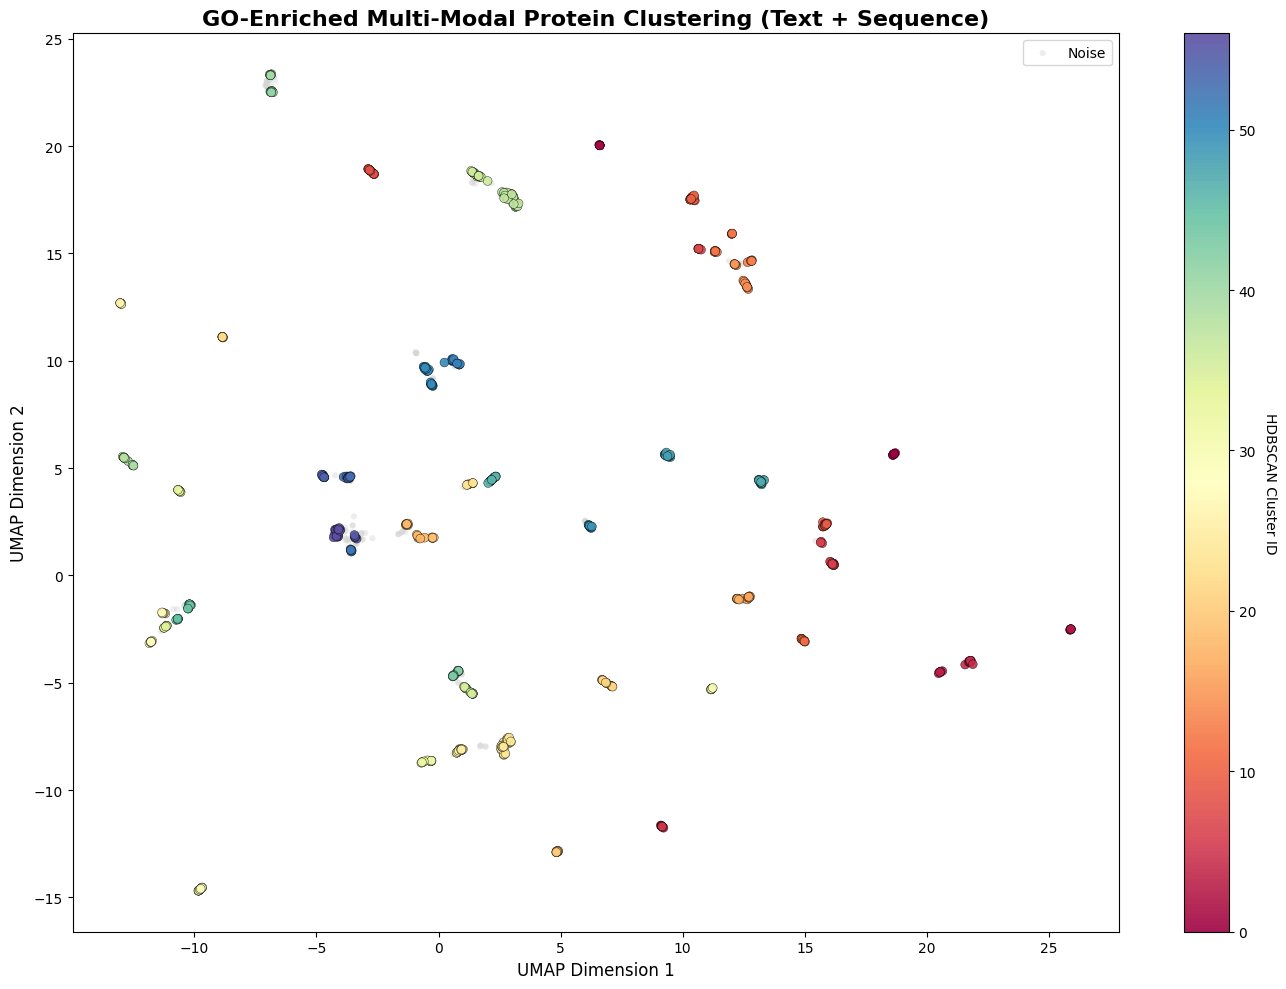

Plot saved.


In [8]:
import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(
    n_components=2,
    metric='precomputed',
    random_state=42,
    n_neighbors=15,
    min_dist=0.1
)
embeddings_2d = reducer.fit_transform(super_matrix_dist)

fig, ax = plt.subplots(figsize=(14, 10))

# Plot noise in gray
noise_mask = labels == -1
ax.scatter(
    embeddings_2d[noise_mask, 0], embeddings_2d[noise_mask, 1],
    c='lightgray', s=20, alpha=0.4, label='Noise', edgecolors='none'
)

# Plot clusters with color map
cluster_mask = labels != -1
scatter = ax.scatter(
    embeddings_2d[cluster_mask, 0], embeddings_2d[cluster_mask, 1],
    c=labels[cluster_mask], cmap='Spectral', s=40, alpha=0.9,
    edgecolors='black', linewidth=0.3
)

ax.set_title('GO-Enriched Multi-Modal Protein Clustering (Text + Sequence)', fontsize=16, fontweight='bold')
ax.set_xlabel('UMAP Dimension 1', fontsize=12)
ax.set_ylabel('UMAP Dimension 2', fontsize=12)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('HDBSCAN Cluster ID', rotation=270, labelpad=15)
ax.legend(loc='upper right')
plt.tight_layout()

os.makedirs('../results/figures', exist_ok=True)
plt.savefig('../results/figures/go_enriched_umap_clusters.png', dpi=300)
plt.show()
print('Plot saved.')

**Cell 9 — Save Final Results**

In [9]:
labeled_seqs = pd.read_csv('../data/processed/sequences_labeled_full.csv')
labeled_seqs = labeled_seqs.rename(columns={'uniref_id': 'ID'})

final_df = pd.merge(
    text_df,
    labeled_seqs[['ID', 'sequence', 'subfamily']],
    on='ID', how='left'
)

columns_to_keep = [
    'super_cluster', 'ID', 'Protein names', 'Gene Names',
    'Keywords', 'Gene Ontology (GO)', 'GO_rich_text',
    'Function [CC]', 'sequence', 'subfamily'
]
final_df = final_df[columns_to_keep]
final_df = final_df.sort_values('super_cluster').reset_index(drop=True)

out_path = '../data/processed/final_multimodal_clusters_go_enriched.csv'
final_df.to_csv(out_path, index=False)

print(f'Saved to: {out_path}')
print(f'Shape   : {final_df.shape}')
print(final_df.head())

Saved to: ../data/processed/final_multimodal_clusters_go_enriched.csv
Shape   : (1037, 10)
   super_cluster          ID  \
0             -1  A0A814T3H0   
1             -1  A0A193KUM9   
2             -1  A0A812E1W5   
3             -1  A0A2R5LMI2   
4             -1      G3M7W2   

                                       Protein names         Gene Names  \
0  G-protein coupled receptors family 1 profile d...  SEV965_LOCUS18641   
1                                             GCR050             gcr050   
2                                               HTR4         SPHA_64522   
3  Putative tyramine/octopamine receptor-like pro...                NaN   
4  Beta-2 adrenergic receptor (Beta-2 adrenocepto...              ADRB2   

                                            Keywords  \
0  Cell membrane;Disulfide bond;G-protein coupled...   
1  Cell membrane;Disulfide bond;G-protein coupled...   
2  Cell membrane;Disulfide bond;G-protein coupled...   
3  Cell membrane;G-protein coupled recept